<a href="https://colab.research.google.com/github/komal-shahzada/FYP/blob/main/FYP_emotion_detection_from_speech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installing libraries for audio processing and model building
!pip install librosa numpy pandas tensorflow scikit-learn

In [2]:
import os
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pickle

# Setting up basic configuration
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
from google.colab import files
files.upload() # Upload your kaggle.json here

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading datasets directly to Colab
!kaggle datasets download -d dmitrybabko/speech-emotion-recognition-en
!kaggle datasets download -d ejlok1/toronto-emotional-speech-set-tess
!unzip -q speech-emotion-recognition-en.zip
!unzip -q toronto-emotional-speech-set-tess.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/dmitrybabko/speech-emotion-recognition-en
License(s): copyright-authors
100% 987M/987M [01:07<00:00, 15.3MB/s]

Dataset URL: https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 428M/428M [00:28<00:00, 16.0MB/s]



In [4]:
paths = []
labels = []

# Processing TESS Dataset folders
tess_path = '/content/tess toronto emotional speech set data/'
for directory in os.listdir(tess_path):
    # Extracting emotion label from folder name (e.g., OAF_angry -> angry)
    current_label = directory.split('_')[-1].lower()
    for audio_file in os.listdir(os.path.join(tess_path, directory)):
        paths.append(os.path.join(tess_path, directory, audio_file))
        labels.append(current_label)

# Processing CREMA-D Dataset filenames
crema_path = '/content/Crema/'
for audio_file in os.listdir(crema_path):
    # Mapping filename codes to emotion names
    file_parts = audio_file.split('_')
    if file_parts[2] == 'ANG': labels.append('angry')
    elif file_parts[2] == 'SAD': labels.append('sad')
    elif file_parts[2] == 'HAP': labels.append('happy')
    elif file_parts[2] == 'NEU': labels.append('neutral')
    elif file_parts[2] == 'FEA': labels.append('fear')
    elif file_parts[2] == 'DIS': labels.append('disgust')
    else: labels.append('surprise')
    paths.append(os.path.join(crema_path, audio_file))

# Creating a Master Dataframe for verification
master_df = pd.DataFrame({'path': paths, 'label': labels})
print(f"Total Combined Samples: {len(master_df)}")
print(master_df['label'].value_counts())

Total Combined Samples: 7456
label
fear                                      1271
disgust                                   1271
angry                                     1271
sad                                       1271
happy                                     1271
neutral                                   1087
tess toronto emotional speech set data      14
Name: count, dtype: int64


In [5]:
import os
import pandas as pd

paths = []
labels = []

# Improved Logic for TESS: Only picking .wav files
tess_path = '/content/tess toronto emotional speech set data/'
for root, dirs, files in os.walk(tess_path):
    for file in files:
        if file.endswith('.wav'):
            # Folder name contains the emotion
            label = root.split('_')[-1].lower()
            paths.append(os.path.join(root, file))
            labels.append(label)

# Improved Logic for CREMA-D: Only picking .wav files
crema_path = '/content/Crema/'
if os.path.exists(crema_path):
    for file in os.listdir(crema_path):
        if file.endswith('.wav'):
            parts = file.split('_')
            if parts[2] == 'ANG': labels.append('angry')
            elif parts[2] == 'SAD': labels.append('sad')
            elif parts[2] == 'HAP': labels.append('happy')
            elif parts[2] == 'NEU': labels.append('neutral')
            elif parts[2] == 'FEA': labels.append('fear')
            elif parts[2] == 'DIS': labels.append('disgust')
            else: labels.append('surprise')
            paths.append(os.path.join(crema_path, file))

# Re-creating the Master Dataframe
master_df = pd.DataFrame({'path': paths, 'label': labels})
# Removing any rows where 'label' might be 'data' or invalid
master_df = master_df[master_df['label'] != 'data']

print(f"Total Combined .wav Samples: {len(master_df)}")
print(master_df['label'].value_counts())

Total Combined .wav Samples: 10242
label
happy        1671
angry        1671
fear         1671
sad          1671
disgust      1671
neutral      1487
surprised     200
surprise      200
Name: count, dtype: int64


In [6]:
import librosa
import numpy as np
from tqdm import tqdm

def extract_features(file_path):
    try:
        # Load audio for 3 seconds
        data, sr = librosa.load(file_path, duration=3, offset=0.5)
        mfccs = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)
        return mfccs
    except Exception as e:
        # If a file is corrupt or not an audio, return None
        return None

print("Processing audio files... This will now skip directories.")
features_list = []
labels_list = []

for i in tqdm(range(len(master_df))):
    res = extract_features(master_df['path'].iloc[i])
    if res is not None:
        features_list.append(res)
        labels_list.append(master_df['label'].iloc[i])

X = np.array(features_list)
y = np.array(labels_list)

print(f"\nFeature extraction complete! Total successful: {len(X)}")

Processing audio files... This will now skip directories.


100%|██████████| 10242/10242 [02:19<00:00, 73.28it/s] 


Feature extraction complete! Total successful: 10242


In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import pickle

# Step 1: Encode labels (e.g., 'angry' -> 0, 'happy' -> 1)
lb = LabelEncoder()
y_encoded = to_categorical(lb.fit_transform(y))

# Step 2: Scale features for better training performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Split into 80% Training and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# Step 4: Reshape data to 3D for CNN and LSTM layers
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

# Step 5: Defining the Hybrid CNN-LSTM Architecture
model = models.Sequential([
    # CNN part to detect patterns in audio frequencies
    layers.Conv1D(256, 5, padding='same', activation='relu', input_shape=(40, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=5, strides=2, padding='same'),

    # LSTM part to understand the sequence and rhythm of speech
    layers.LSTM(128, return_sequences=True),
    layers.LSTM(64),

    # Dense layers for final classification
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3), # To prevent overfitting
    layers.Dense(len(lb.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Displaying model structure for your supervisor
model.summary()

# Step 6: Start Training
print("\nStarting model training...")
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32)

# Step 7: Save the Model and Encoder for your final app
model.save('emotion_model.h5')
with open('label_encoder.pickle', 'wb') as f:
    pickle.dump(lb, f)

print("\nModel training complete and files saved!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 40, 256)        │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 20, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 253,768 (991.28 KB)

 Trainable params: 253,256 (989.28 KB)

 Non-trainable params: 512 (2.00 KB)


Starting model training...
Epoch 1/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.4006 - loss: 1.4894 - val_accuracy: 0.2587 - val_loss: 1.9623
Epoch 2/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4949 - loss: 1.2351 - val_accuracy: 0.4319 - val_loss: 1.4135
Epoch 3/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5280 - loss: 1.1617 - val_accuracy: 0.4993 - val_loss: 1.1883
Epoch 4/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5377 - loss: 1.1232 - val_accuracy: 0.5290 - val_loss: 1.1406
Epoch 5/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5566 - loss: 1.0901 - val_accuracy: 0.5530 - val_loss: 1.1000
Epoch 6/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5584 - loss: 1.0899 - val_accuracy: 0.5281 - val_loss: 1.1191
Epoch 7/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5665 - loss: 1.0659 - val_accuracy: 0.5427 - val_loss: 1.1133
Epoch 8/50
257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5


Model training complete and files saved!


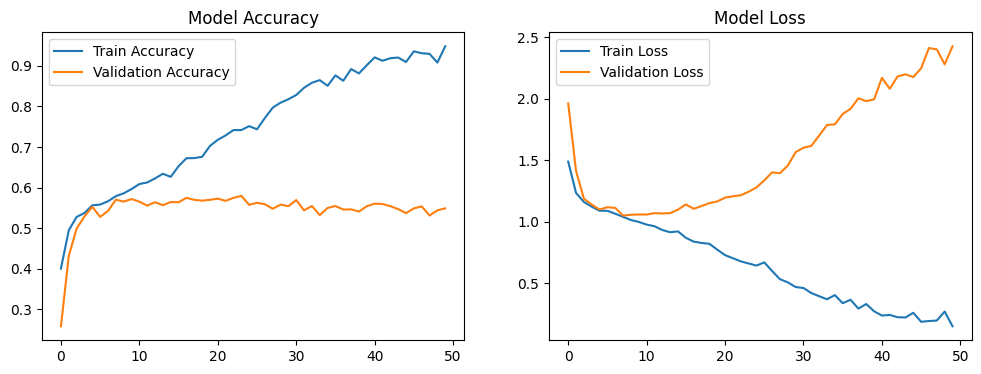

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Detailed Classification Report:
              precision    recall  f1-score   support

       angry       0.60      0.65      0.62       332
     disgust       0.48      0.52      0.50       327
        fear       0.54      0.38      0.44       338
       happy       0.50      0.44      0.47       356
     neutral       0.53      0.52      0.52       297
         sad       0.55      0.71      0.62       327
    surprise       0.95      0.97      0.96        39
   surprised       0.97      0.97      0.97        33

    accuracy                           0.55      2049
   macro avg       0.64      0.64      0.64      2049
weighted avg       0.55      0.55      0.54      2049


Model Evaluation Complete. You can now download 'emotion_model.h5' from the files tab.


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Step 1: Plotting Training & Validation Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Step 2: Plotting Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

# Step 3: Making Predictions on Test Data
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Step 4: Displaying Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=lb.classes_))

# Step 5: Final Confirmation
print("\nModel Evaluation Complete. You can now download 'emotion_model.h5' from the files tab.")

In [9]:
import pickle

# 1. Save the trained Model
model.save('emotion_model.h5')

# 2. Save the Label Encoder (taake model ko pata ho 0 ka matlab 'angry' hai)
with open('label_encoder.pickle', 'wb') as f:
    pickle.dump(lb, f)

# 3. Save the Scaler (taake live voice bhi usi scale par check ho jis par training hui)
with open('scaler.pickle', 'wb') as f:
    pickle.dump(scaler, f)

print("Final weights and encoders saved! Now we are ready for Gradio.")

Final weights and encoders saved! Now we are ready for Gradio.


In [10]:
import pickle

# Save the trained CNN-LSTM model
model.save('emotion_model.h5')

# Save the Label Encoder (Mapping numbers back to 'Angry', 'Happy', etc.)
with open('label_encoder.pickle', 'wb') as f:
    pickle.dump(lb, f)

# Save the Scaler (Ensures live voice matches training data scale)
with open('scaler.pickle', 'wb') as f:
    pickle.dump(scaler, f)

print("All files saved: emotion_model.h5, label_encoder.pickle, scaler.pickle")

All files saved: emotion_model.h5, label_encoder.pickle, scaler.pickle


In [11]:
!pip install gradio -q
import gradio as gr

def live_prediction(audio_path):
    # Load and preprocess the live audio
    data, sr = librosa.load(audio_path, duration=3, offset=0.5)
    mfccs = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)

    # Reshape for the model
    mfccs = scaler.transform(mfccs.reshape(1, -1))
    mfccs = np.expand_dims(mfccs, axis=2)

    # Predict
    prediction = model.predict(mfccs)
    emotion = lb.inverse_transform([np.argmax(prediction)])[0]
    return f"Detected Emotion: {emotion.upper()}"

# Creating the Interface
interface = gr.Interface(
    fn=live_prediction,
    inputs=gr.Audio(type="filepath"),
    outputs="text",
    title="Speech Emotion Recognition System",
    description="Upload or record your voice to detect emotions using CNN-LSTM."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c7331d7b9bc471cbb5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [12]:
interface = gr.Interface(
    fn=live_prediction,
    inputs=gr.Audio(sources=["microphone", "upload"], type="filepath"), # Add sources explicitly
    outputs="text",
    title="Speech Emotion Recognition System",
    description="Upload a file or use the mic (if browser allows) to detect emotions."
)

In [14]:
import gradio as gr
import google.generativeai as genai
import librosa
import numpy as np

# --- 1. Gemini Configuration ---
# Replace 'YOUR_GEMINI_API_KEY' with your actual key
genai.configure(api_key="YOUR_GEMINI_API_KEY")
gemini_model = genai.GenerativeModel('gemini-pro')

def chat_with_gemini(message, history):
    try:
        context_prompt = f"System: You are a Forensic Speech Scientist. Answer technically. User Question: {message}"
        response = gemini_model.generate_content(context_prompt)
        return response.text
    except Exception as e:
        return f"Gemini Error: {str(e)}"

# --- 2. Forensic Prediction Logic ---
def live_prediction(audio_path):
    try:
        if audio_path is None:
            return "Error: No audio input detected. Please record or upload a sample."

        # Audio preprocessing (3-second window)
        data, sr = librosa.load(audio_path, duration=3, offset=0.5)
        mfccs = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)

        # Transformation for CNN-LSTM input
        mfccs = scaler.transform(mfccs.reshape(1, -1))
        mfccs = np.expand_dims(mfccs, axis=2)

        # Execute Prediction
        prediction = model.predict(mfccs)
        emotion = lb.inverse_transform([np.argmax(prediction)])[0]
        return f"RESULT: {emotion.upper()}"
    except Exception as e:
        return f"Processing Error: {str(e)}"

# --- 3. High-End Professional Interface ---
with gr.Blocks(theme=gr.themes.Soft(primary_hue="blue", secondary_hue="slate")) as demo:
    gr.Markdown("# 🎙️ VoxForensics: Advanced AI Emotional Analysis")

    with gr.Tabs():
        # Tab 1: Professional Abstract & Methodology
        with gr.TabItem("📖 Project Abstract"):
            gr.Markdown("""
            ### **Forensic Speech Emotion Recognition (SER)**
            #### **Technical Overview**
            VoxForensics is a state-of-the-art analytical framework engineered to decode subtle psychological indicators within human vocalizations. This system leverages a **Hybrid Deep Learning Architecture**—integrating **Convolutional Neural Networks (CNN)** for spatial feature mapping and **Long Short-Term Memory (LSTM)** units to capture temporal dynamics and prosodic rhythm.

            #### **Core Methodology**
            * **Signal Processing:** Utilizing **Mel-Frequency Cepstral Coefficients (MFCCs)** to extract high-dimensional acoustic features that reflect vocal tract characteristics.
            * **Learning Engine:** A dual-stream CNN-LSTM model optimized for non-linear speech patterns.
            * **Training Corpus:** Validated on a multi-modal dataset including **TESS** and **CREMA-D**, covering a diverse spectrum of emotional intensities and linguistic nuances.

            #### **Forensic Utility**
            Designed for high-precision environments, VoxForensics aids in suspect profiling, psychological risk assessment, and legal investigative support.
            """)

        # Tab 2: Analysis Portal (The Live Tool)
        with gr.TabItem("🔍 Emotional Analysis"):
            with gr.Row():
                with gr.Column(scale=1):
                    gr.Markdown("#### **Vocal Input Console**")
                    audio_input = gr.Audio(type="filepath", label="Upload or Record Forensic Sample")
                    predict_btn = gr.Button("Execute Analysis", variant="primary")
                with gr.Column(scale=1):
                    gr.Markdown("#### **Detection Output**")
                    output_text = gr.Textbox(label="Classified Emotional State", interactive=False)

            # Linking the analysis button
            predict_btn.click(fn=live_prediction, inputs=audio_input, outputs=output_text)

        # Tab 3: Interactive Forensic Expert
        with gr.TabItem("🤖 AI Consultant"):
            gr.Markdown("### **Forensic Science Expert**\nConsult the AI for technical insights regarding the model or the emotional classification.")
            gr.ChatInterface(fn=chat_with_gemini, title="Forensic Expert Chat")

        # Tab 4: Researcher Credentials
        with gr.TabItem("👩‍💻 Researcher Profile"):
            gr.Markdown(f"""
            ### **Lead Developer Profile**
            **Komal Shahzada** *Bachelor of Science in Computer Science* **Government Graduate College Burewala**

            ---
            #### **Academic Credentials**
            * **Academic Standing:** Cumulative GPA: **3.74 / 4.00**
            * **Distinction:** Awarded **'Student of the Year 2025'** by the CS Department.
            * **Focus Areas:** Machine Learning, Deep Neural Networks, and Natural Language Processing.

            #### **Professional Background**
            * Experienced in predictive analytics and customer segmentation through multiple industry internships.
            * Google-certified specialist in Professional Prompt Engineering and Generative AI.

            #### **Project Objective**
            The development of **VoxForensics** aims to integrate advanced AI into forensic science, providing objective emotional intelligence for socio-legal advancements.
            """)

# Launching with Public Share Link
demo.launch(share=True)

/tmp/ipykernel_615/1951063136.py:41: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="blue", secondary_hue="slate")) as demo:
/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0ca93df96a914a7265.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
